In [4]:
import os
import matplotlib.pyplot as plt
from PIL import Image

In [7]:
# Paths = [best zero-shot, best visual few-shot]
paths = [
    '/home/gridsan/manderson/ovdsat/run/eval/detection/qual/dior/text_prototypes/backbone_remoteclip-14_boxes/0.5/zeroshot_1/figures',
    '/home/gridsan/manderson/ovdsat/run/eval/detection/qual/dior/init_prototypes/backbone_dinov2_boxes/N10-1/figures',
    '/home/gridsan/manderson/ovdsat/run/eval/detection/qual/dior/coop_prototypes/backbone_remoteclip-14_boxes/dior_remoteclip_new/nctx4_cscFalse_ctpend/0.5/N10-1/figures'
        ]

# Names shown above each prediction
method_names = [
    'Best Zero-Shot (RemoteCLIP)',
    'Best Visual 10-Shot (DINOv2)',
    'Best TARPLE (RemoteCLIP)'
]

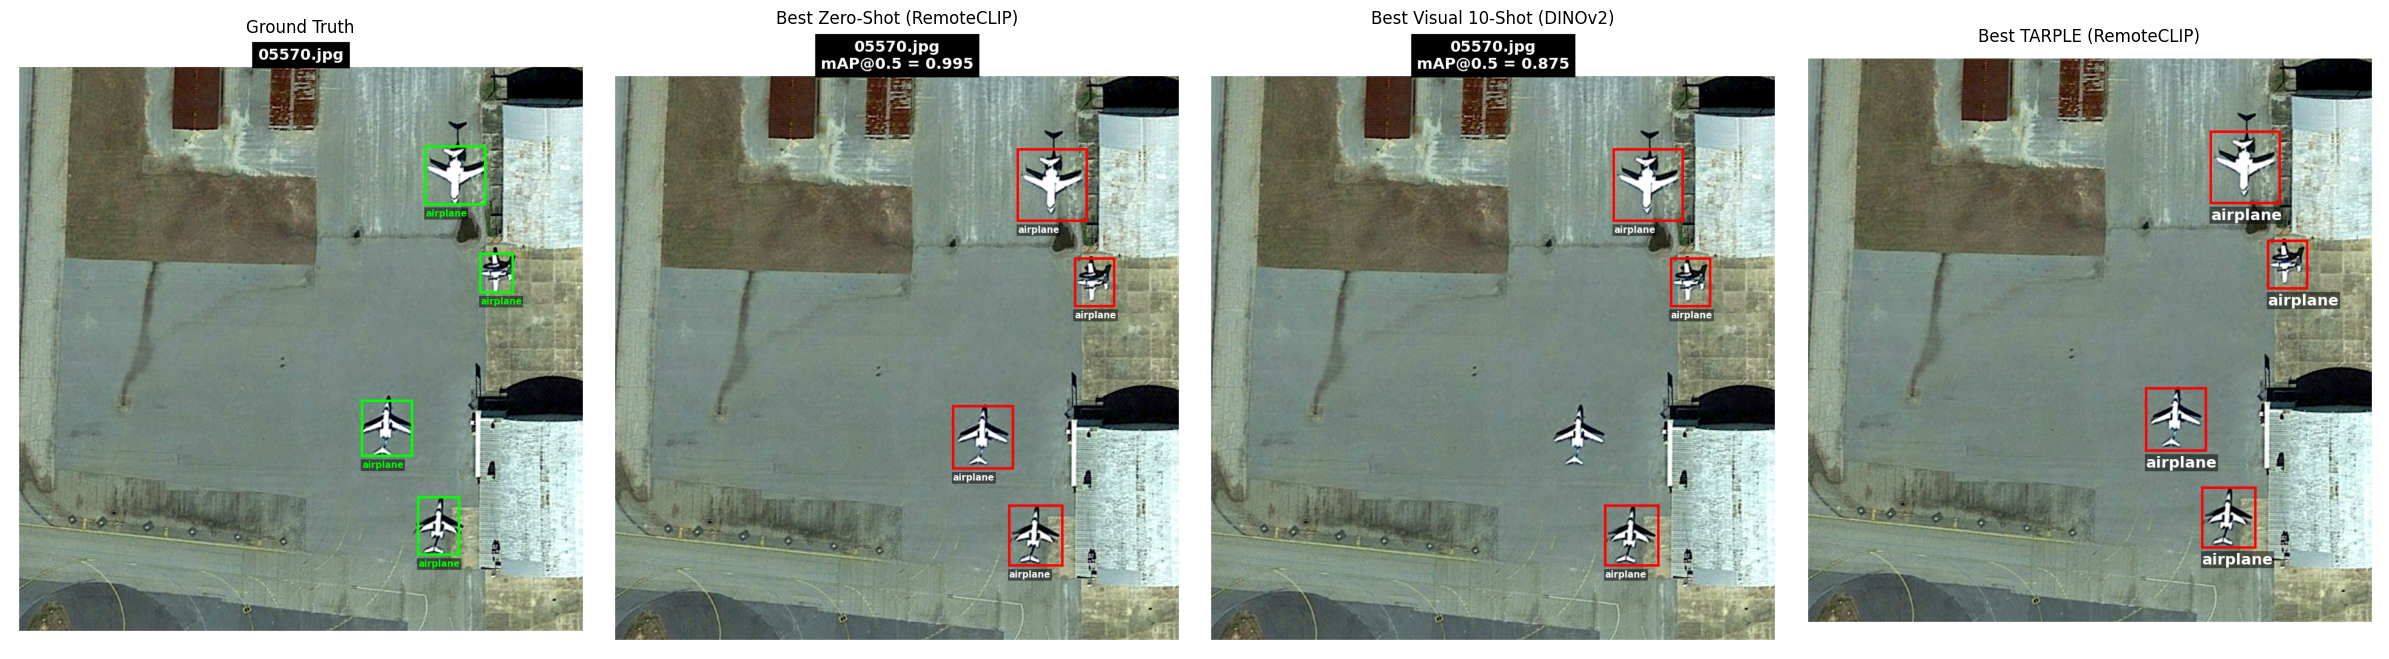

In [8]:
# Choose batch & image
batch_num = 0
img_num = 3

gt_filename = f'batch{batch_num}_img{img_num}_ground_truth.png'
pred_filename = f'batch{batch_num}_img{img_num}_prediction.png'

if len(paths) != len(method_names):
    raise ValueError('paths and method_names must have the same length')

# Ground truth is identical across folders, so load it from the first one
gt_path = os.path.join(paths[0], gt_filename)

if not os.path.exists(gt_path):
    raise FileNotFoundError(f'File not found: {gt_path}')

gt_image = Image.open(gt_path).convert('RGB')

# Load each method's prediction
prediction_images = []

for path in paths:
    pred_path = os.path.join(path, pred_filename)

    if not os.path.exists(pred_path):
        raise FileNotFoundError(f'File not found: {pred_path}')

    prediction_images.append(Image.open(pred_path).convert('RGB'))

# Plot ground truth followed by all method predictions
num_columns = 1 + len(paths)
fig, axes = plt.subplots(1, num_columns, figsize=(6 * num_columns, 7))

# Handle the case where there is only one method
if num_columns == 1:
    axes = [axes]

axes[0].imshow(gt_image)
axes[0].set_title('Ground Truth')
axes[0].axis('off')

for i, (prediction_image, method_name) in enumerate(
    zip(prediction_images, method_names),
    start=1
):
    axes[i].imshow(prediction_image)
    axes[i].set_title(method_name)
    axes[i].axis('off')

plt.tight_layout()
plt.show()